# Forward Stepwise Selection

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

## 1. Load data

In [3]:
diabetes = load_diabetes(as_frame=True)

X = diabetes.data
y = diabetes.target

df = pd.DataFrame(X, columns=load_diabetes().feature_names)

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## 2. Split data

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (353, 10)
X_test shape: (89, 10)
y_train shape: (353,)
y_test shape: (89,)


## 3. Implement Forward Stepwise Selection

**Algorithm**:
1. let $M_{0}$ denote the null model, which contains no predictors.
2. For $k=0,\dots,p-1$:
    - Consider all $p-k$ models that augment the predictors in $M_{k}$ with one additional predictor.
    - Choose the best among these $p-k$ models, and call it $M_{k+1}$. Here *best* is defined as having smallest RSS or highest $R^2$.
3. Select a single best model from among $M_{0},\dots,M_{p}$ sing the prediction error on a validation set, Or use the cross-validation method.

In [10]:
results = []
selected_features = []
remaining_features = list(X_train.columns)

for k in range(X_train.shape[1]):
    candidates = []
    for feature in remaining_features:
        current_features = selected_features + [feature]

        model = LinearRegression()
        model.fit(X_train[current_features], y_train)
        y_pred = model.predict(X_train[current_features])

        rss = np.sum((y_train - y_pred) ** 2)

        candidates.append((rss, feature))

    best_rss, best_feature = min(
        candidates,
        key=lambda x: x[0]
    )

    selected_features.append(best_feature)
    remaining_features.remove(best_feature)

    results.append(
        (best_rss, selected_features.copy())
    )


In [12]:
for i, result in enumerate(results, start=1):
    print(f"({i}) RSS: {result[0]}, {result[1]}")

(1) RSS: 1360501.7661827644, ['bmi']
(2) RSS: 1161834.7519467813, ['bmi', 's5']
(3) RSS: 1108649.5035964558, ['bmi', 's5', 'bp']
(4) RSS: 1074425.5272317056, ['bmi', 's5', 'bp', 's1']
(5) RSS: 1053574.059740825, ['bmi', 's5', 'bp', 's1', 's2']
(6) RSS: 1022172.2639890872, ['bmi', 's5', 'bp', 's1', 's2', 'sex']
(7) RSS: 1016695.1037401556, ['bmi', 's5', 'bp', 's1', 's2', 'sex', 's4']
(8) RSS: 1015027.3246336151, ['bmi', 's5', 'bp', 's1', 's2', 'sex', 's4', 's6']
(9) RSS: 1013490.0819656126, ['bmi', 's5', 'bp', 's1', 's2', 'sex', 's4', 's6', 's3']
(10) RSS: 1012598.0451009588, ['bmi', 's5', 'bp', 's1', 's2', 'sex', 's4', 's6', 's3', 'age']


### 3.1 Plot RSS Values

10
range(1, 11)


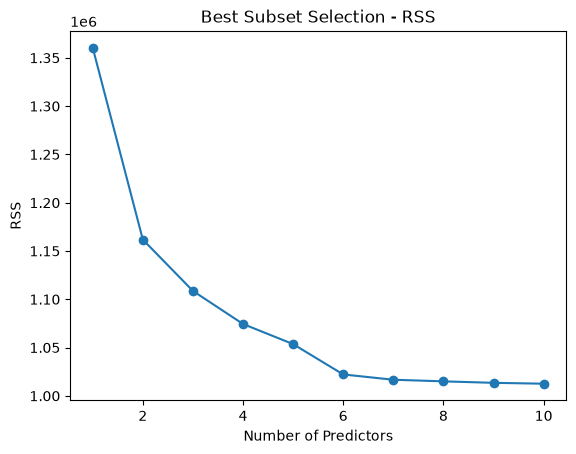

In [13]:
rss_values = [x[0] for x in results]
print(len(rss_values))
model_sizes = range(1, len(results) + 1)
print(model_sizes)

plt.plot(model_sizes, rss_values, marker="o")
plt.xlabel("Number of Predictors")
plt.ylabel("RSS")
plt.title("Best Subset Selection - RSS")
plt.show();

### 3.4 Adjusted R-Squared

In [14]:
def r_squared(y, y_pred):
    # Calculate Residual sum of squares
    ss_res = np.sum((y - y_pred) ** 2)

    # calculate total sum of squares
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    r_squared_val = 1 - (ss_res / ss_tot)

    return r_squared_val

In [15]:
def adjusted_r_squared(y, y_pred, k):
    n = y.shape[0]
    return 1 - ((1 - r_squared(y, y_pred)) * (n - 1)) / (n - k - 1)

In [25]:
results = []

selected_features = []
remaining_features = list(X_train.columns)

for k in range(X_train.shape[1]):

    candidates = []

    for feature in remaining_features:

        current_features = selected_features + [feature]

        model = LinearRegression()
        model.fit(X_train[current_features], y_train)

        y_pred = model.predict(X_train[current_features])

        rss = np.sum((y_train - y_pred) ** 2)

        adj_r2 = adjusted_r_squared(
            y_train,
            y_pred,
            k=len(current_features)
        )

        candidates.append(
            (rss, adj_r2, feature)
        )

    # Forward-selection decision
    best_rss, best_adj_r2, best_feature = min(
        candidates,
        key=lambda x: x[0]
    )

    selected_features.append(best_feature)
    remaining_features.remove(best_feature)

    results.append(
        (
            best_rss,
            best_adj_r2,
            selected_features.copy()
        )
    )

In [26]:
for i, (rss, adj_r2, features) in enumerate(results, start=1):
    print(f"({i}) RSS: {rss}, Adjusted R^2: {adj_r2}, {feature}")

(1) RSS: 1360501.7661827644, Adjusted R^2: 0.3639170736112628, age
(2) RSS: 1161834.7519467813, Adjusted R^2: 0.45524896592010855, age
(3) RSS: 1108649.5035964558, Adjusted R^2: 0.47869656698400165, age
(4) RSS: 1074425.5272317056, Adjusted R^2: 0.49333743285592735, age
(5) RSS: 1053574.059740825, Adjusted R^2: 0.5017384903957364, age
(6) RSS: 1022172.2639890872, Adjusted R^2: 0.515192043489128, age
(7) RSS: 1016695.1037401556, Adjusted R^2: 0.5163921051833983, age
(8) RSS: 1015027.3246336151, Adjusted R^2: 0.5157818812076433, age
(9) RSS: 1013490.0819656126, Adjusted R^2: 0.5151056452003355, age
(10) RSS: 1012598.0451009588, Adjusted R^2: 0.5141158596208325, age


In [28]:
best_adj_r2_model = max(
    results,
    key=lambda x: x[1]
)
best_adj_r2_model

(np.float64(1016695.1037401556),
 np.float64(0.5163921051833983),
 ['bmi', 's5', 'bp', 's1', 's2', 'sex', 's4'])

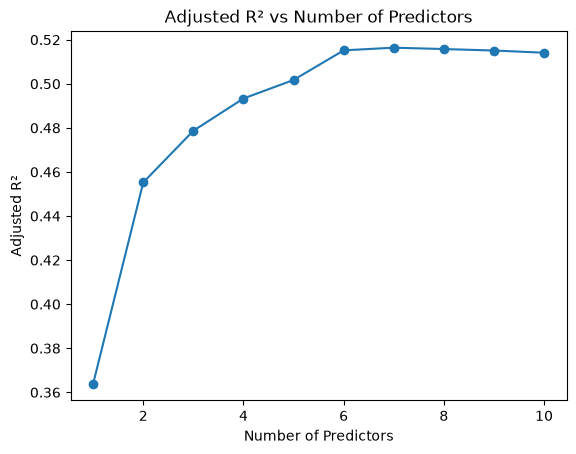

In [29]:
adj_r2_values = [result[1] for result in results]

plt.plot(
    range(1, len(results) + 1),
    adj_r2_values,
    marker="o"
)

plt.xlabel("Number of Predictors")
plt.ylabel("Adjusted R²")
plt.title("Adjusted R² vs Number of Predictors")

plt.show()

### 3.5 Bayseeian Information Criterion (BIC)

In [30]:
def bic(y, y_pred, num_predictors):
    n = len(y)

    rss = np.sum((y - y_pred) ** 2)

    # predictors + intercept
    k = num_predictors + 1

    return n * np.log(rss / n) + k * np.log(n)

In [31]:
results = []

selected_features = []
remaining_features = list(X_train.columns)

for k in range(X_train.shape[1]):

    candidates = []

    for feature in remaining_features:

        current_features = selected_features + [feature]

        model = LinearRegression()
        model.fit(X_train[current_features], y_train)

        y_pred = model.predict(X_train[current_features])

        rss = np.sum((y_train - y_pred) ** 2)

        adj_r2 = adjusted_r_squared(
            y_train,
            y_pred,
            k=len(current_features)
        )

        bic_value = bic(
            y_train,
            y_pred,
            k
        )

        candidates.append(
            (rss, adj_r2, bic_value, feature)
        )

    # Forward-selection decision
    best_rss, best_adj_r2, best_bic, best_feature = min(
        candidates,
        key=lambda x: x[0]
    )

    selected_features.append(best_feature)
    remaining_features.remove(best_feature)

    results.append(
        (
            best_rss,
            best_adj_r2,
            best_bic,
            selected_features.copy()
        )
    )

In [32]:
for i, (rss, adj_r2, bic, features) in enumerate(results, start=1):
    print(f"({i}) RSS: {rss}, Adjusted R^2: {adj_r2}, BIC: {bic} {feature}")

(1) RSS: 1360501.7661827644, Adjusted R^2: 0.3639170736112628, BIC: 2920.550783752544 age
(2) RSS: 1161834.7519467813, Adjusted R^2: 0.45524896592010855, BIC: 2870.695093693581 age
(3) RSS: 1108649.5035964558, Adjusted R^2: 0.47869656698400165, BIC: 2860.020748774851 age
(4) RSS: 1074425.5272317056, Adjusted R^2: 0.49333743285592735, BIC: 2854.818377381808 age
(5) RSS: 1053574.059740825, Adjusted R^2: 0.5017384903957364, BIC: 2853.766795592248 age
(6) RSS: 1022172.2639890872, Adjusted R^2: 0.515192043489128, BIC: 2848.9521129745203 age
(7) RSS: 1016695.1037401556, Adjusted R^2: 0.5163921051833983, BIC: 2852.92199643802 age
(8) RSS: 1015027.3246336151, Adjusted R^2: 0.5157818812076433, BIC: 2858.2089304517 age
(9) RSS: 1013490.0819656126, Adjusted R^2: 0.5151056452003355, BIC: 2863.5403804073167 age
(10) RSS: 1012598.0451009588, Adjusted R^2: 0.5141158596208325, BIC: 2869.096013975501 age


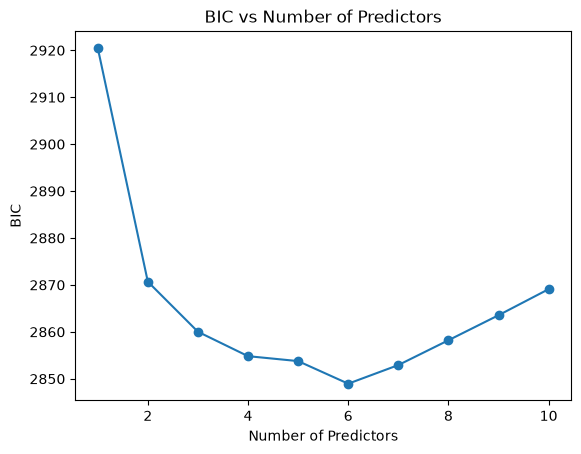

In [33]:
bic_values = [result[2] for result in results]

plt.plot(
    range(1, len(results) + 1),
    bic_values,
    marker="o"
)

plt.xlabel("Number of Predictors")
plt.ylabel("BIC")
plt.title("BIC vs Number of Predictors")
plt.show()

In [34]:
def forward_selection(X, y, k):
    selected_features = []
    remaining_features = list(X.columns)

    for _ in range(k):
        candidates = []

        for feature in remaining_features:
            current_features = selected_features + [feature]

            model = LinearRegression()
            model.fit(X[current_features], y)

            y_pred = model.predict(X[current_features])

            rss = np.sum((y - y_pred) ** 2)

            candidates.append((rss, feature))

        best_rss, best_feature = min(
            candidates,
            key=lambda x: x[0]
        )

        selected_features.append(best_feature)
        remaining_features.remove(best_feature)

    return selected_features